In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.integrate import odeint
import h5py
import math

from mpl_toolkits.mplot3d import axes3d
%matplotlib widget

In [2]:
# dat = np.loadtxt("./peak-integrated_sensitivities/pis_s.dat")
LISA = np.loadtxt("./power-law-integrated_sensitivities/plis_LISA.dat")
BBO = np.loadtxt("./power-law-integrated_sensitivities/plis_BBO.dat")
DECIGO = np.loadtxt("./power-law-integrated_sensitivities/plis_DECIGO.dat")

ET = np.loadtxt("./power-law-integrated_sensitivities/plis_ET.dat")
CE = np.loadtxt("./power-law-integrated_sensitivities/plis_CE.dat")

HLVO2 = np.loadtxt("./power-law-integrated_sensitivities/plis_HLVO2.dat")

In [10]:
# results=np.loadtxt("./results.dat")
# results=np.loadtxt("./results.12")
results=np.loadtxt("./results_fin4.dat")

In [11]:
np.arange(0,len(results),5)

array([ 0,  5, 10, 15])

In [12]:
markers=[".", "+", "x", "v"] # "v", "1", 
colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'] #list(mcolors.BASE_COLORS)

In [13]:
import matplotlib.colors as mcolors

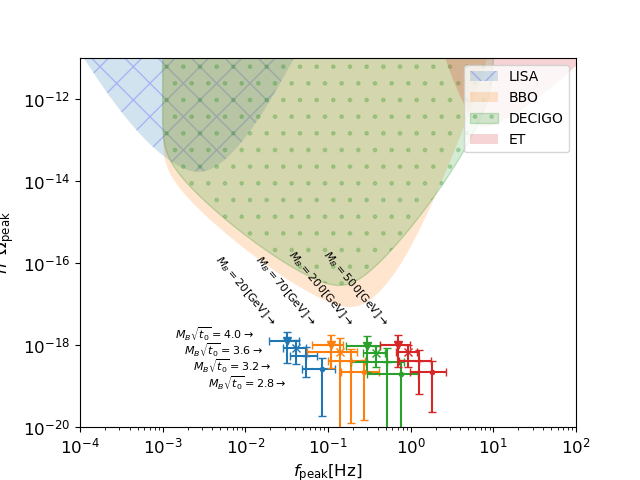

In [42]:
plt.clf()

fig = plt.figure()
ax = plt.axes()

# d=np.zeros(len(dat))+1.0

ax.fill_between( 10**LISA.T[0], 10**LISA.T[1], 1.0, label="LISA", 
                hatch="X", 
                edgecolor="b", linewidth=0.0, alpha=0.2 )
ax.fill_between( 10**BBO.T[0], 10**BBO.T[1], 1.0, label="BBO", alpha=0.2 )
ax.fill_between( 10**DECIGO.T[0], 10**DECIGO.T[1], 1.0, label="DECIGO",
                hatch=".", 
                edgecolor="g", alpha=0.2 )

ax.fill_between( 10**ET.T[0], 10**ET.T[1], 1.0, label="ET", alpha=0.2 )
# ax.fill_between( 10**HLVO2.T[0], 10**HLVO2.T[1], 1.0, label="HLVO2", alpha=0.2 )

#######################################

nn=4

# results=results[::-1]
for i in range(nn):
    tmp = results[i*nn:(i+1)*nn]
    for im in range(len(tmp)):
        tmp2 = tmp[im]
        if i==im:
            ax.errorbar( x=tmp2[3], y=tmp2[4], 
                            xerr=tmp2[5], yerr=tmp2[6],
                           ls='none', capsize=3,
                           marker=markers[im],
                            c=colors[i],
                           # label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$"
                           ) # , label="$M_B="+str(num)+"$GeV"
        else:
            ax.errorbar( x=tmp2[3], y=tmp2[4], 
            xerr=tmp2[5], yerr=tmp2[6],
           ls='none', capsize=3,
           marker=markers[im],
            c=colors[i],
           ) # , label="$M_B="+str(num)+"$GeV"

    # ax.errorbar( x=results[i*nn:(i+1)*nn].T[3], y=results[i*nn:(i+1)*nn].T[4], 
    #             xerr=results[i*nn:(i+1)*nn].T[5], yerr=results[i*nn:(i+1)*nn].T[6],
    #            ls='none', capsize=3,
    #            marker=markers[i],
    #            label="MB="+str(int(results[i*nn][0]))+"[GeV]") # , label="$M_B="+str(num)+"$GeV"

# for i, txt in enumerate(n):
#     txt2 = '{:.2f}'.format(txt)
#     ax.annotate(txt2, (x[i], y[i]))



plt.xscale("log")
plt.yscale("log")

plt.ylim(10**-20, 10**-11)
plt.xlim(10**-4, 100)


plt.legend(loc='upper right')

# plt.title("power-law-integrated sensitivity; annotation is $T_*$ in GeV")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("$f_{\\rm peak}$[Hz]", fontsize=12)
plt.ylabel("$h^2\\Omega_{\\rm peak}$", fontsize=12)


plt.text(0.0014, 1.4e-18, "$M_B\\sqrt{t_0}=4.0 \\rightarrow$", fontsize=8)
plt.text(0.0018, 5.7e-19, "$M_B\\sqrt{t_0}=3.6 \\rightarrow$", fontsize=8)
plt.text(0.0023, 2.3e-19, "$M_B\\sqrt{t_0}=3.2 \\rightarrow$", fontsize=8)
plt.text(0.0035, 0.9e-19, "$M_B\\sqrt{t_0}=2.8 \\rightarrow$", fontsize=8)

plt.text(0.0039, 3.e-18, "$M_B=20 {\\rm [GeV]} \\rightarrow$", fontsize=8, rotation=-50)
plt.text(0.012, 3.e-18, "$M_B=70 {\\rm [GeV]} \\rightarrow$", fontsize=8, rotation=-50)
plt.text(0.03, 3.e-18, "$M_B=200 {\\rm [GeV]} \\rightarrow$", fontsize=8, rotation=-50)
plt.text(0.08, 3.e-18, "$M_B=500 {\\rm [GeV]} \\rightarrow$", fontsize=8, rotation=-50)

plt.savefig("sensitivity.pdf", bbox_inches='tight')
plt.show()

In [13]:
results.T[12]

array([0.16444562, 0.16886724, 0.17329086, 0.17771248, 0.16444162,
       0.16886524, 0.17328686, 0.17770648, 0.16443962, 0.16886124,
       0.17328086, 0.17770048, 0.16443762, 0.16885924, 0.17327886,
       0.17769648])

In [14]:
results.T[13]

array([0.16457362, 0.16906124, 0.17354886, 0.17803648, 0.16457362,
       0.16906124, 0.17354886, 0.17803648, 0.16457362, 0.16906124,
       0.17354886, 0.17803648, 0.16457362, 0.16906124, 0.17354886,
       0.17803648])

In [13]:
results.T[14]

array([0.00298321, 0.00391885, 0.00485445, 0.00579084, 0.0029829 ,
       0.00391764, 0.00485527, 0.00579062, 0.00298367, 0.00391758,
       0.00485417, 0.0057906 , 0.00298318, 0.00391766, 0.00485429,
       0.00578977])

In [14]:
results.T[15]

array([0.00298367, 0.00392339, 0.00486461, 0.0058066 , 0.00298367,
       0.00392339, 0.00486461, 0.0058066 , 0.00298367, 0.00392339,
       0.00486461, 0.0058066 , 0.00298367, 0.00392339, 0.00486461,
       0.0058066 ])

In [15]:
results.T[16]

array([ 1.15353483,  1.04620855,  0.96272145,  0.89592677,  4.03732189,
        3.66166431,  3.3694473 ,  3.1356212 , 11.53506255, 10.46171053,
        9.62677007,  8.9586677 , 28.83747781, 26.15380758, 24.06636962,
       22.39604425])

In [16]:
results.shape

(16, 24)

In [43]:
# fig = plt.figure()
# ax = plt.axes()

# for i in range(nn):
#     tmp = results[i*nn:(i+1)*nn]
#     for im in range(len(tmp)):
#         tmp2 = tmp[im]
#         # print(tmp2)
#         if i==im:
#             plt.errorbar( tmp2[1]*1.005**(+i-2.5), tmp2[13], tmp2[15],
#                          ls='none',
#                          capsize=3,
#                     marker=markers[im],
#                             c=colors[i],
#                         label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$")
#         else:
#             plt.errorbar( tmp2[1]*1.005**(+i-2.5), tmp2[13], tmp2[15],
#                          ls='none',
#                          capsize=3,
#                     marker=markers[im],
#                             c=colors[i],)
#            #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
#            #  xerr=tmp2[5], yerr=tmp2[6],
#            # ls='none', capsize=3,
#            # marker=markers[im],
#            #  c=colors[i],
#            # )
# plt.legend()
# plt.xscale("log")
# plt.yscale("log")

# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# plt.ylabel("$T_c$", fontsize=12)
# plt.xlabel("$M_B$ [GeV]", fontsize=12)

# plt.savefig("Tc_MB.pdf", bbox_inches='tight')

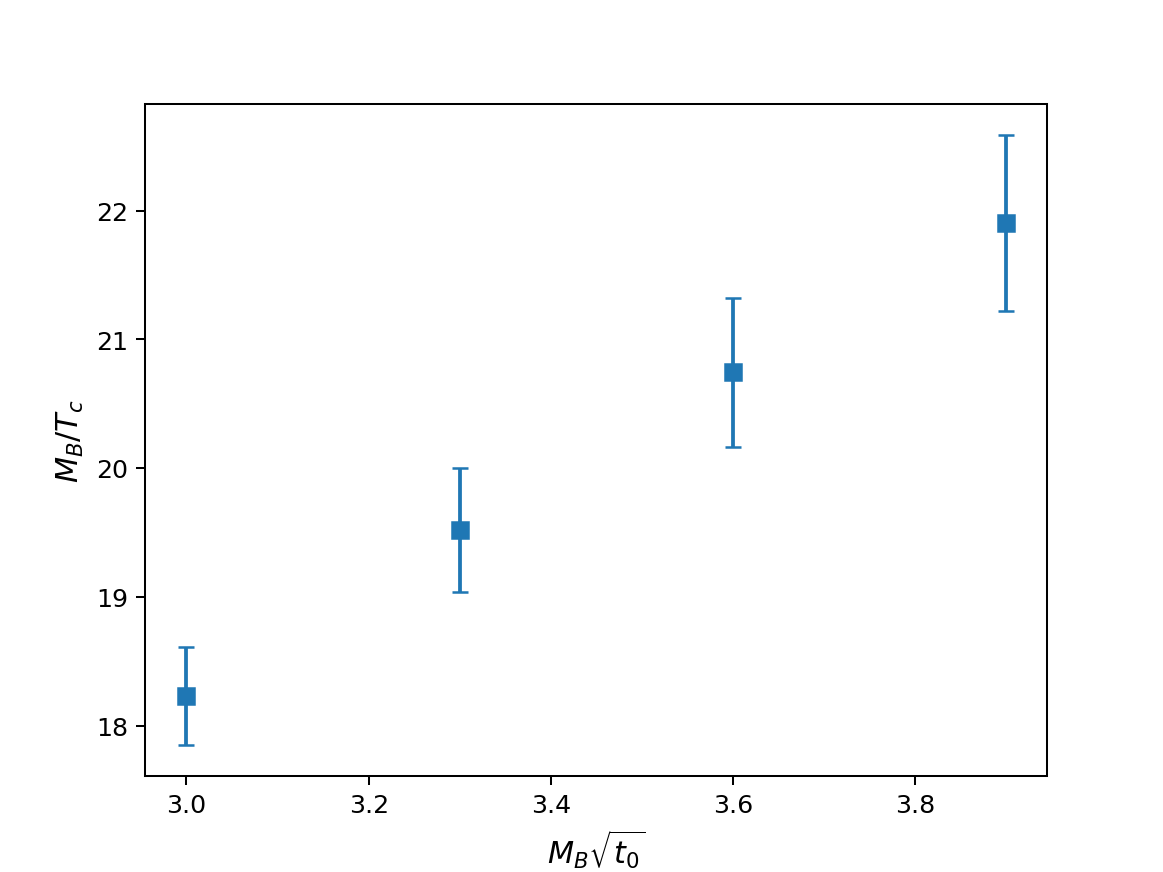

In [82]:
xx=results[:nn].T[1]
yy=results[:nn].T[20]
dyy=results[:nn].T[21]

plt.clf()
plt.errorbar( xx, yy, dyy,
            ls='none',
             capsize=3, marker='s')

plt.ylabel("$M_B/T_c$", fontsize=12)
plt.xlabel("$M_B \\sqrt{t_0}$", fontsize=12)

plt.savefig("MBOverTc_MB.pdf", bbox_inches='tight')
plt.show()

In [26]:
results[:nn].T[1]

array([3. , 3.3, 3.6, 3.9])

In [19]:
tmp2[20]

18.228923695334515

In [20]:
tmp2[21]

0.3822345154129437

Text(0.5, 0, '$M_B \\sqrt{t_0}$ [GeV]')

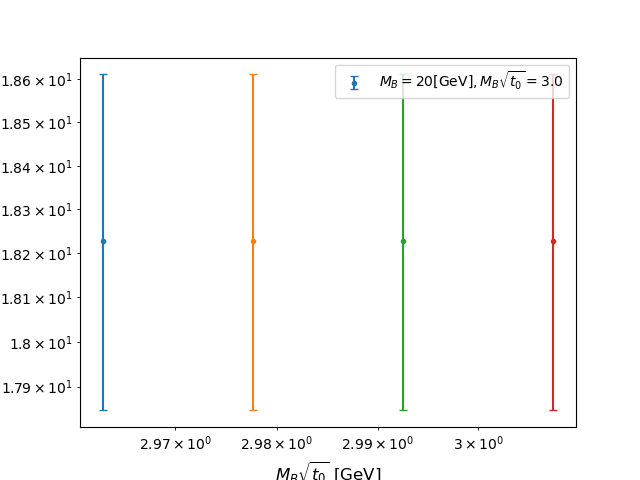

In [78]:
# fig = plt.figure()
# ax = plt.axes()

# for i in range(nn):
#     tmp = results[i*nn:(i+1)*nn]
#     # for im in range(len(tmp)):
#     im=0
#     tmp2 = tmp[im]
#     # print(tmp2)
#     if i==im:
#         plt.errorbar( tmp2[1]*1.005**(+i-2.5), tmp2[20], tmp2[21],
#                      ls='none',
#                      capsize=3,
#                 marker=markers[im],
#                         c=colors[i],
#                     label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$")
#     else:
#         plt.errorbar( tmp2[1]*1.005**(+i-2.5), tmp2[20], tmp2[21],
#                      ls='none',
#                      capsize=3,
#                 marker=markers[im],
#                         c=colors[i],)
#            #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
#            #  xerr=tmp2[5], yerr=tmp2[6],
#            # ls='none', capsize=3,
#            # marker=markers[im],
#            #  c=colors[i],
#            # )
# plt.legend()
# plt.xscale("log")
# plt.yscale("log")

# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# plt.ylabel("$M_B/T_c$", fontsize=12)
# plt.xlabel("$M_B \\sqrt{t_0}$ [GeV]", fontsize=12)

# # plt.savefig("Tc_MB.pdf", bbox_inches='tight')

In [50]:
'{:.3f}'.format(tmp2[13])

'0.178'

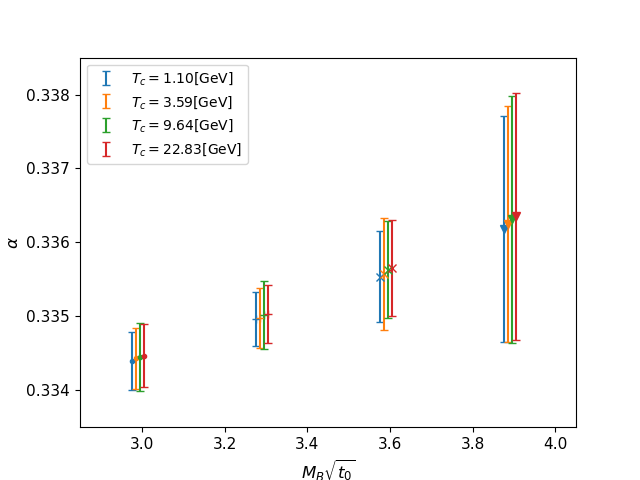

In [75]:
fig = plt.figure()
ax = plt.axes()

for i in range(nn):
    tmp = results[i*nn:(i+1)*nn]
    for im in range(len(tmp)):
        tmp2 = tmp[im]
        if i==im:
            plt.errorbar( -1.0, 1.0, 1.0,
                     ls='none',
                    marker='none',
                         capsize=3,
                        c=colors[i],
                        label="$T_c="+'{:.2f}'.format(tmp2[17])+"{\\rm [GeV]}$")

            plt.errorbar( tmp2[1]+0.01*(+i-2.5), tmp2[7], tmp2[10],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],
                        # label="$T_c="+'{:.3f}'.format(tmp2[13])+"{\\rm [GeV]}$"
                        )
        else:
            plt.errorbar( tmp2[1]+0.01*(+i-2.5), tmp2[7], tmp2[10],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],)
           #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
           #  xerr=tmp2[5], yerr=tmp2[6],
           # ls='none', capsize=3,
           # marker=markers[im],
           #  c=colors[i],
           # )
plt.legend()
# plt.xscale("log")
# plt.yscale("log")

plt.xlim(2.85, 4.05)
plt.ylim(0.3335, 0.3385)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.ylabel("$\\alpha$", fontsize=12)
plt.xlabel("$M_B \\sqrt{t_0}$", fontsize=12)

plt.savefig("alpha_MB.pdf", bbox_inches='tight')

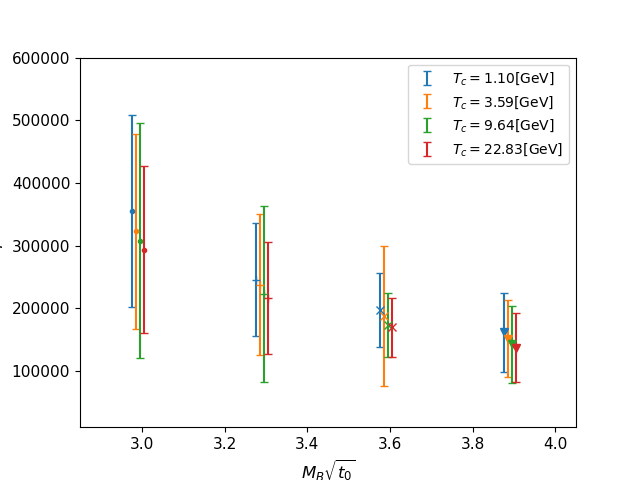

In [74]:
fig = plt.figure()
ax = plt.axes()

for i in range(nn):
    tmp = results[i*nn:(i+1)*nn]
    for im in range(len(tmp)):
        tmp2 = tmp[im]
        if i==im:
            plt.errorbar( -1.0, 1.0, 1.0,
                     ls='none',
                    marker='none',
                         capsize=3,
                        c=colors[i],
                        label="$T_c="+'{:.2f}'.format(tmp2[17])+"{\\rm [GeV]}$")

            plt.errorbar( tmp2[1]+0.01*(+i-2.5), tmp2[9], tmp2[11],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],
                        # label="$T_c="+'{:.3f}'.format(tmp2[13])+"{\\rm [GeV]}$"
                        )
        else:
            plt.errorbar( tmp2[1]+0.01*(+i-2.5), tmp2[9], tmp2[11],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],)
           #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
           #  xerr=tmp2[5], yerr=tmp2[6],
           # ls='none', capsize=3,
           # marker=markers[im],
           #  c=colors[i],
           # )
plt.legend()
# plt.xscale("log")
# plt.yscale("log")

plt.xlim(2.85, 4.05)
plt.ylim(10.0**4, 6*10.0**5)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.ylabel("$\\tilde\\beta$", fontsize=12)
plt.xlabel("$M_B \\sqrt{t_0}$", fontsize=12)

plt.savefig("betatilde_MB.pdf", bbox_inches='tight')

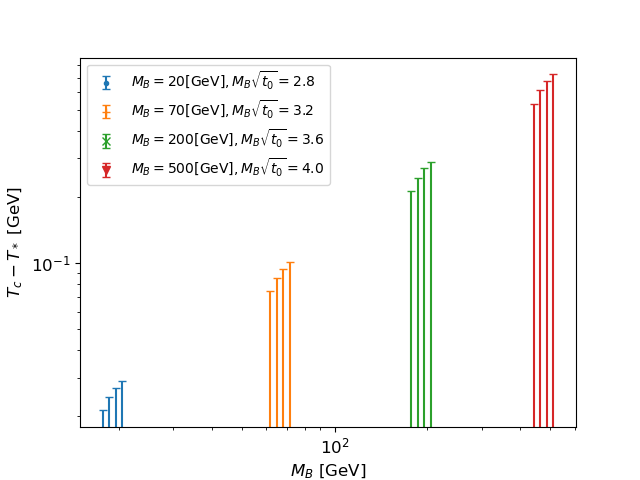

In [9]:
fig = plt.figure()
ax = plt.axes()

for i in range(nn):
    tmp = results[i*nn:(i+1)*nn]
    for im in range(len(tmp)):
        tmp2 = tmp[im]
        if i==im:
            plt.errorbar( tmp2[0]*1.05**(+im-2.5), tmp2[15]-tmp2[14], tmp2[18],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],
                        label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$")
        else:
            plt.errorbar( tmp2[0]*1.05**(+im-2.5), tmp2[15]-tmp2[14], tmp2[18],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],)
           #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
           #  xerr=tmp2[5], yerr=tmp2[6],
           # ls='none', capsize=3,
           # marker=markers[im],
           #  c=colors[i],
           # )
plt.legend()
plt.xscale("log")
plt.yscale("log")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.ylabel("$T_c-T_*$ [GeV]", fontsize=12)
plt.xlabel("$M_B$ [GeV]", fontsize=12)

plt.savefig("TcmTstar_MB.pdf", bbox_inches='tight')

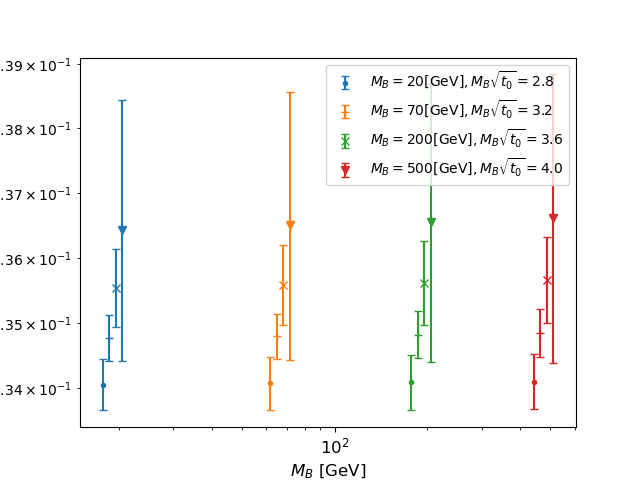

In [10]:
fig = plt.figure()
ax = plt.axes()

for i in range(nn):
    tmp = results[i*nn:(i+1)*nn]
    for im in range(len(tmp)):
        tmp2 = tmp[im]
        if i==im:
            plt.errorbar( tmp2[0]*1.05**(+im-2.5), tmp2[7], tmp2[10],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],
                        label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$")
        else:
            plt.errorbar( tmp2[0]*1.05**(+im-2.5), tmp2[7], tmp2[10],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],)
           #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
           #  xerr=tmp2[5], yerr=tmp2[6],
           # ls='none', capsize=3,
           # marker=markers[im],
           #  c=colors[i],
           # )
plt.legend()
plt.xscale("log")
plt.yscale("log")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.ylabel("$\\alpha$", fontsize=12)
plt.xlabel("$M_B$ [GeV]", fontsize=12)

plt.savefig("alpha_MB.pdf", bbox_inches='tight')

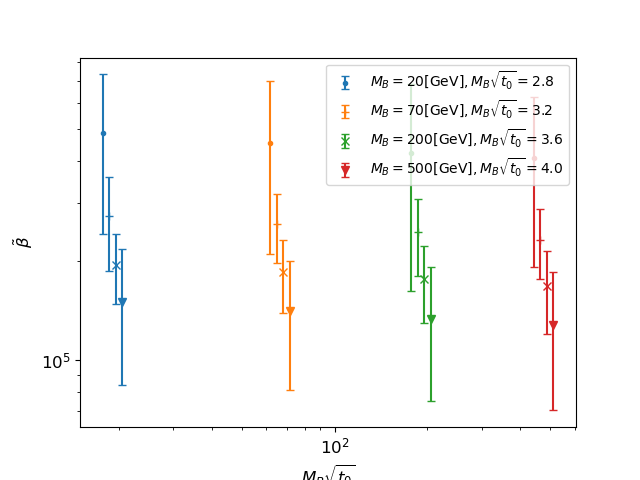

In [11]:
fig = plt.figure()
ax = plt.axes()

for i in range(nn):
    tmp = results[i*nn:(i+1)*nn]
    for im in range(len(tmp)):
        tmp2 = tmp[im]
        if i==im:
            plt.errorbar( tmp2[0]*1.05**(+im-2.5), tmp2[9], tmp2[11],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],
                        label="$M_B="+str(int(tmp2[0]))+"{\\rm [GeV]}, M_B\\sqrt{t_0}="+str(tmp2[1])+"$")
        else:
            plt.errorbar( tmp2[0]*1.05**(+im-2.5), tmp2[9], tmp2[11],
                         ls='none',
                         capsize=3,
                    marker=markers[im],
                            c=colors[i],)
           #  ax.errorbar( x=tmp2[3], y=tmp2[4], 
           #  xerr=tmp2[5], yerr=tmp2[6],
           # ls='none', capsize=3,
           # marker=markers[im],
           #  c=colors[i],
           # )
plt.legend()
plt.xscale("log")
plt.yscale("log")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.ylabel("$\\tilde\\beta$", fontsize=12)
plt.xlabel("$M_B \\sqrt{t_0}$", fontsize=12)

plt.savefig("beta_MB.pdf", bbox_inches='tight')

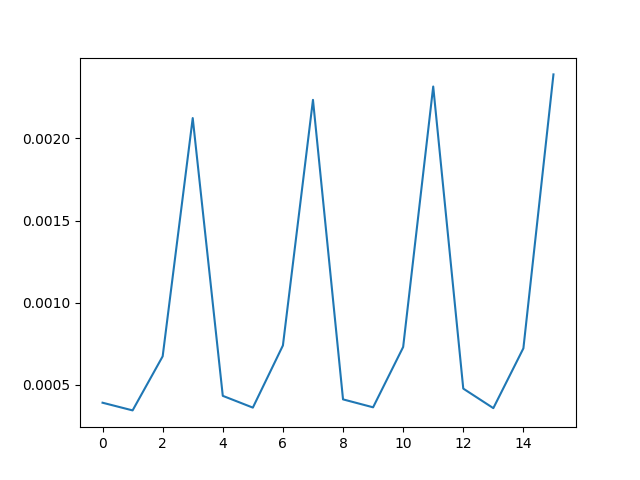

In [16]:
plt.clf()
plt.plot( results.T[10] )
results.T[11]
plt.show()

In [141]:
results.T[11]

array([0.16443425, 0.17110715, 0.17778004, 0.18445293, 0.16443425,
       0.17110715, 0.17778004, 0.18445293, 0.16443425, 0.17110715,
       0.17778004, 0.18445293, 0.16443425, 0.17110715, 0.17778004,
       0.18445293])

In [10]:
results[6*i::6]

NameError: name 'i' is not defined

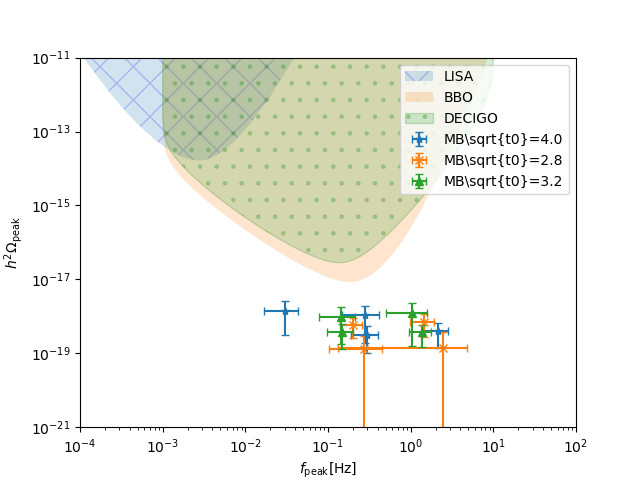

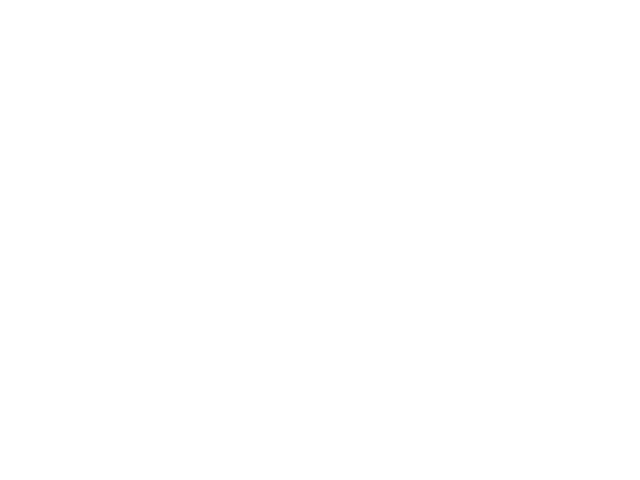

In [11]:
plt.clf()

fig = plt.figure()
ax = plt.axes()

# d=np.zeros(len(dat))+1.0

ax.fill_between( 10**LISA.T[0], 10**LISA.T[1], 1.0, label="LISA", 
                hatch="X", 
                edgecolor="b", linewidth=0.0, alpha=0.2 )
ax.fill_between( 10**BBO.T[0], 10**BBO.T[1], 1.0, label="BBO", alpha=0.2 )
ax.fill_between( 10**DECIGO.T[0], 10**DECIGO.T[1], 1.0, label="DECIGO",
                hatch=".", 
                edgecolor="g", alpha=0.2 )
# ax.fill_between( 10**HLVO2.T[0], 10**HLVO2.T[1], 1.0, label="HLVO2", alpha=0.2 )

#######################################5

i=3
ax.errorbar( x=results[i::6].T[3], y=results[i::6].T[4], 
            xerr=results[i::6].T[5], yerr=results[i::6].T[6],
           ls='none', capsize=3,
           marker=markers[i],
           label="MB\sqrt{t0}="+str(results[i][1])) # , label="$M_B="+str(num)+"$GeV"
i=4
ax.errorbar( x=results[i::6].T[3], y=results[i::6].T[4], 
            xerr=results[i::6].T[5], yerr=results[i::6].T[6],
           ls='none', capsize=3,
           marker=markers[i],
           label="MB\sqrt{t0}="+str(results[i][1])) # , label="$M_B="+str(num)+"$GeV"
i=5
ax.errorbar( x=results[i::6].T[3], y=results[i::6].T[4], 
            xerr=results[i::6].T[5], yerr=results[i::6].T[6],
           ls='none', capsize=3,
           marker=markers[i],
           label="MB\sqrt{t0}="+str(results[i][1])) # , label="$M_B="+str(num)+"$GeV"
# for i, txt in enumerate(n):
#     txt2 = '{:.2f}'.format(txt)
#     ax.annotate(txt2, (x[i], y[i]))



plt.xscale("log")
plt.yscale("log")

plt.ylim(10**-21, 10**-11)
plt.xlim(10**-4, 100)


plt.legend()

# plt.title("power-law-integrated sensitivity; annotation is $T_*$ in GeV")

plt.xlabel("$f_{\\rm peak}$[Hz]")
plt.ylabel("$h^2\\Omega_{\\rm peak}$")

plt.show()